# Invariant Mass Fit of $J/\psi$ and $\psi(2S)$ Mesons

## 1. Setup and Data Loading
**Physical Motivation:** In high-energy physics, we cannot directly detect short-lived particles. Instead, we measure the kinematics of their decay products. By applying conservation of energy and momentum, we calculate the **invariant mass** of the original parent particle. True particle decays manifest as resonance peaks in this mass spectrum.

Here, we configure our environment to use the interactive JSROOT inline viewer while enforcing strict batch mode to prevent X11 crashes. Then, we load the invariant mass dataset.

**Physical Motivation: Invariant Mass and Resonances**
In high-energy physics, short-lived particles like the $J/\psi$ and $\psi(2S)$ mesons decay almost instantaneously. Detectors instead measure the momentum vectors of their decay products. Using special relativity, we reconstruct the **invariant mass** of the original parent particle. 

True particle decays appear as Gaussian resonance peaks centered at the particle's true mass. Random, unrelated particle combinations create a continuous combinatorial background (usually an exponential shape). 

Our objective is to use an **Extended Maximum Likelihood Fit** to separate these overlapping shapes. By doing an extended fit, we treat the expected number of events as a Poisson-fluctuating variable, yielding the most mathematically rigorous statistical uncertainties for our signal yields and shapes.

In [1]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# Prevent X11 ROOT in batch mode
ROOT.gROOT.SetBatch(True)
ROOT.RooMsgService.instance().setGlobalKillBelow(ROOT.RooFit.ERROR)
ROOT.RooMsgService.instance().setSilentMode(True)

# Enable interactive JSROOT viewer and high-res matplotlib
%jsroot on
%matplotlib inline
%config InlineBackend.figure_format='retina'

ROOT.gStyle.SetOptStat(0)
ROOT.gStyle.SetOptTitle(0)
ROOT.gStyle.SetTextFont(42)
ROOT.gStyle.SetLegendFont(42)
# Apply ROOT styling
#ROOT.gStyle.SetOptStat(0)
#ROOT.gStyle.SetOptTitle(0)

# Load the dataset
inputFile = ROOT.TFile.Open("data/jpsi_single_mass.root")
tree = inputFile.Get("tree")

# Define the observable: Invariant Mass range (2100 - 4200 MeV)
x = ROOT.RooRealVar("JpsiMass", "Invariant Mass [MeV/c^{2}]", 2100., 4200.)
data = ROOT.RooDataSet("data", "data", ROOT.RooArgSet(x), ROOT.RooFit.Import(tree))

## 2. Defining the Fit Parameters and Model
**Physical Phenomena:** 
The data contains two expected bound charm-anticharm states:
* The $J/\psi$ meson (narrow, highly abundant, peaking near 3100 MeV).
* The excited $\psi(2S)$ meson (wider, far fewer events, peaking near 3686 MeV).
* A combinatorial background caused by the detector randomly pairing unrelated tracks. This follows an exponential decay.

We use an **Extended Maximum Likelihood Fit**. By introducing yield parameters (`N1`, `N2`, `N3`), the fit treats the total number of events as a Poisson-distributed variable. This provides the most accurate statistical uncertainties for the extracted particle yields.

**Why these specific PDFs?**
* **Signal 1 ($J/\psi$):** Modeled as a `RooGaussian`. The $J/\psi$ is extremely abundant and has a sharp peak around 3096 MeV.
* **Signal 2 ($\psi(2S)$):** Modeled as a second `RooGaussian`. It is a heavier, excited state of the charmonium family, peaking around 3686 MeV. It has a much lower yield, making it harder to distinguish from the background.
* **Background:** Modeled as a `RooExponential`. 

We combine these using a `RooAddPdf`. By supplying three yield parameters (`N1`, `N2`, `N3`), we perform an *Extended* fit. This means the total number of expected events is treated as a Poisson-fluctuating variable, which yields more accurate statistical errors for the particle counts than fitting simple fractions.

In [2]:
# Signal 1: J/psi (Gaussian)
mean1 = ROOT.RooRealVar("mean1", "Mean of J/psi", 3100, 3040, 3150.)
sigma1 = ROOT.RooRealVar("sigma1", "Width of J/psi", 100., 10., 300.)
gauss1 = ROOT.RooGaussian("gauss1", "J/psi Signal", x, mean1, sigma1)

# Signal 2: psi(2S) (Gaussian)
mean2 = ROOT.RooRealVar("mean2", "Mean of psi(2S)", 3600, 3540, 3950.)
sigma2 = ROOT.RooRealVar("sigma2", "Width of psi(2S)", 100., 10., 400.)
gauss2 = ROOT.RooGaussian("gauss2", "psi(2S) Signal", x, mean2, sigma2)

# Background (Exponential)
tau = ROOT.RooRealVar("tau", "Decay constant", -0.001, -0.01, 0.0)
bck = ROOT.RooExponential("bck", "Combinatorial Background", x, tau)

# Event Yields for the Extended Fit
N1 = ROOT.RooRealVar("N1", "Yield J/psi", 1000, 0.0, 10000)
N2 = ROOT.RooRealVar("N2", "Yield psi(2S)", 1000, 0.0, 10000)
N3 = ROOT.RooRealVar("N3", "Yield Background", 1000, 0.0, 100000)

# Composite Model
TotalPDF = ROOT.RooAddPdf("TotalPDF", "Total Model", 
                           ROOT.RooArgList(gauss1, gauss2, bck), 
                           ROOT.RooArgList(N1, N2, N3))

## 3. Minimization and Contour Generation
We construct the Negative Log-Likelihood (NLL) function and minimize it using MINUIT (`RooMinimizer`). 

**Parameter Correlation ($\sigma_2$ vs $\tau$):**
Because the $\psi(2S)$ signal has a low yield and sits in the flattening tail of the exponential background, the minimizer struggles to perfectly separate the two shapes. If the background fits slightly steeper (lower $\tau$), the $\psi(2S)$ Gaussian must become wider ($\sigma_2$) to compensate. To quantify this systematic uncertainty, we generate 2D likelihood contours mapping the exact boundary of this correlation at $1\sigma$, $2\sigma$, and $3\sigma$ confidence levels.

**Minimizing the Negative Log-Likelihood (NLL)**
Instead of a simple least-squares fit, we use the Maximum Likelihood method, which is superior for unbinned datasets. `RooMinimizer` uses the MINUIT algorithm to find the minimum of the NLL space.
* `m.hesse()` calculates symmetric errors by taking the second derivative (Hessian matrix) at the minimum.
* `m.minos(sigma2)` calculates exact, asymmetric errors by tracing the NLL profile until it drops by a specified confidence threshold.

**Why focus on the correlation between $\sigma_2$ and $\tau$?**
The second Gaussian ($\psi(2S)$) sits in the tail of the exponential background. Because its yield is low, the minimizer struggles to determine where the background ends and the wide signal begins. If the background steepens (lower $\tau$), the signal width ($\sigma_2$) must artificially widen to cover the data. Mapping this correlation via a 2D contour is crucial to understanding the systematic uncertainty of the $\psi(2S)$ measurement.

In [3]:
# tzv. ROOTe drž hubu!
#ROOT.RooMsgService.instance().setGlobalKillBelow(ROOT.RooFit.WARNING)

# Construct NLL and minimize
nll = TotalPDF.createNLL(data)
m = ROOT.RooMinimizer(nll)
m.minimize("Minuit2", "Migrad")

# Calculate symmetric (Hesse) and asymmetric (Minos) errors
m.hesse()
m.minos(sigma2)

# Generate the 1, 2, and 3-sigma contours for the correlation
frameContour = m.contour(sigma2, tau, 1, 2, 3)

## 4. JSROOT Plotting: Mass Fit
We generate the visualization using ROOT. With `%jsroot on` active, calling `Draw()` will embed an interactive, zoomable Javascript plot directly into the Jupyter output cell.

In [65]:
xframe = x.frame(ROOT.RooFit.Title(""))
data.plotOn(xframe, ROOT.RooFit.Name("Data_Hist"))
TotalPDF.plotOn(xframe, ROOT.RooFit.Name("Fit_Curve"), ROOT.RooFit.LineColor(ROOT.kRed))
TotalPDF.plotOn(xframe, ROOT.RooFit.Components("bck"), ROOT.RooFit.Name("Bck_Curve"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kBlue))
TotalPDF.plotOn(xframe, ROOT.RooFit.Components("gauss1,gauss2"), ROOT.RooFit.Name("Sig_Curve"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kGreen+2))

mass_canvas = ROOT.TCanvas("mass_canvas", "Mass Fit", 800, 600)
mass_canvas.SetLeftMargin(0.12)
xframe.GetYaxis().SetTitleOffset(1.4)
xframe.Draw()

# Add Legend
leg = ROOT.TLegend(0.75, 0.77, 0.9, 0.88)
leg.SetBorderSize(1)
leg.SetTextSize(0.02)
leg.AddEntry("Data_Hist", "Data", "pe")
leg.AddEntry("Fit_Curve", "Total Fit", "l")
leg.AddEntry("Sig_Curve", "Signals", "l")
leg.AddEntry("Bck_Curve", "Background", "l")
leg.Draw()

# Add Fit Parameters Box
param_box = ROOT.TPaveText(0.25, 0.85, 0.45, 0.7, "NDC")
param_box.SetBorderSize(0)
param_box.SetFillColor(0)
param_box.SetTextFont(42)
param_box.SetTextAlign(12)
param_box.AddText(f"N(J/#psi) = {N1.getVal():.0f} #pm {N1.getError():.0f}")
param_box.AddText(f"N(#psi(2S)) = {N2.getVal():.0f} #pm {N2.getError():.0f}")
param_box.AddText(f"#sigma(J/#psi) = {sigma1.getVal():.1f} MeV")
param_box.AddText(f"#sigma(#psi(2S)) = {sigma2.getVal():.1f} MeV")
param_box.Draw()

mass_canvas.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: mass_canvas


## 5. JSROOT Plotting: Contours
Similarly, we draw the generated contour mapping of the $\sigma_2$ and $\tau$ parameters to an interactive inline canvas.

In [5]:
contour_canvas = ROOT.TCanvas("contour_canvas", "Contours", 800, 600)
contour_canvas.SetLeftMargin(0.15)

frameContour.SetTitle("")
frameContour.GetXaxis().SetTitle("Gaussian 2 Width (#sigma_{2}) [MeV/c^{2}]")
frameContour.GetYaxis().SetTitle("Background Decay Parameter (#tau)")
frameContour.GetYaxis().SetTitleOffset(1.6)

# Force zoom on the relevant parameter space
frameContour.GetXaxis().SetLimits(120., 200.)
frameContour.SetMinimum(-0.00105)
frameContour.SetMaximum(-0.00095)

frameContour.Draw()
contour_canvas.Draw()

## 6. Extracting Data for Matplotlib
While JSROOT is excellent for interactive viewing, high-energy physics publications often rely on customized Matplotlib graphics. We extract the raw mathematical vectors from the `RooPlot` objects to gain ultimate formatting control.

*Note: The contour frame contains both `TGraph` objects (the contour rings) and a `TMarker` (the best-fit point). We use `InheritsFrom` to safely route the extraction.*

In [6]:
# Helper to extract lines
def get_curve(xframe, name):
    curve = xframe.findObject(name)
    return np.array([curve.GetPointX(i) for i in range(curve.GetN())]), \
           np.array([curve.GetPointY(i) for i in range(curve.GetN())])

# Helper to extract graphs
def get_graph_data(graph):
    return np.array([graph.GetPointX(i) for i in range(graph.GetN())]), \
           np.array([graph.GetPointY(i) for i in range(graph.GetN())])

# Extract Mass Plot curves
x_fit, y_fit = get_curve(xframe, "Fit_Curve")
x_bck, y_bck = get_curve(xframe, "Bck_Curve")
x_sig, y_sig = get_curve(xframe, "Sig_Curve")

# Extract Histogram Data
hist = xframe.findObject("Data_Hist")
x_data = np.array([hist.GetPointX(i) for i in range(hist.GetN())])
y_data = np.array([hist.GetPointY(i) for i in range(hist.GetN())])
y_err_low = np.array([hist.GetErrorYlow(i) for i in range(hist.GetN())])
y_err_high = np.array([hist.GetErrorYhigh(i) for i in range(hist.GetN())])

# Extract Contours and Best-Fit Marker safely
contours = []
best_fit_x, best_fit_y = None, None

for i in range(int(frameContour.numItems())):
    obj = frameContour.getObject(i)
    if obj.InheritsFrom("TGraph"):
        contours.append(obj)
    elif obj.InheritsFrom("TMarker"):
        best_fit_x = obj.GetX()
        best_fit_y = obj.GetY()

x_c1, y_c1 = get_graph_data(contours[0])
x_c2, y_c2 = get_graph_data(contours[1])
x_c3, y_c3 = get_graph_data(contours[2])

## 7. Matplotlib Publication Plot: Mass Fit
We apply high-energy physics standard aesthetics (inward ticks, serif fonts, retina format) to reconstruct the invariant mass plot.

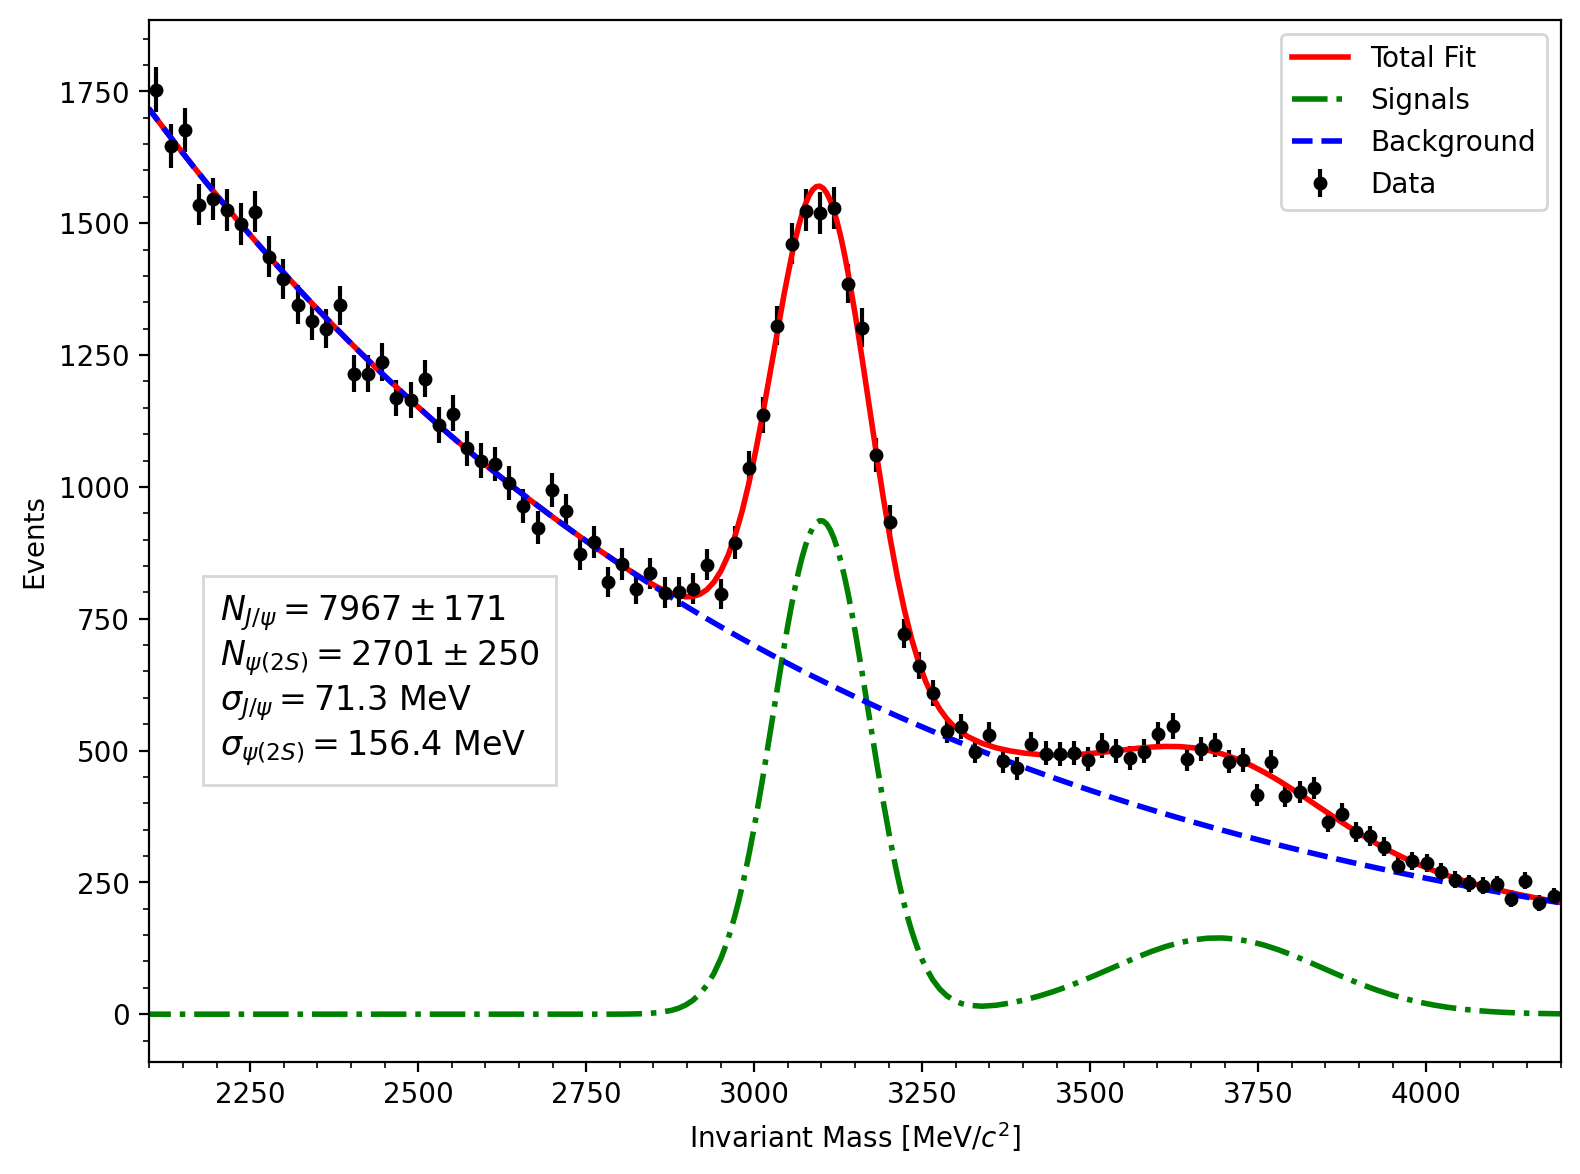

In [7]:
# Global HEP styling for Matplotlib
#plt.rcParams.update({
#    "font.family": "serif",
#    "font.size": 14,
#    "axes.labelsize": 16,
#    "xtick.direction": "in",
#    "ytick.direction": "in",
#    "xtick.top": True,
#    "ytick.right": True,
#    "legend.frameon": False
#})

fig, ax = plt.subplots(figsize=(8, 6))

ax.errorbar(x_data, y_data, yerr=[y_err_low, y_err_high], fmt='o', color='black', markersize=4, label='Data')
ax.plot(x_fit, y_fit, color='red', linewidth=2, label='Total Fit')
ax.plot(x_sig, y_sig, color='green', linestyle='-.', linewidth=2, label='Signals')
ax.plot(x_bck, y_bck, color='blue', linestyle='--', linewidth=2, label='Background')

ax.set_xlabel('Invariant Mass [MeV/$c^{2}$]')
ax.set_ylabel('Events')
ax.set_xlim(2100, 4200)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.legend(loc='upper right')

# Fit Variables Text Box
textstr = '\n'.join((
    r'$N_{J/\psi} = %.0f \pm %.0f$' % (N1.getVal(), N1.getError()),
    r'$N_{\psi(2S)} = %.0f \pm %.0f$' % (N2.getVal(), N2.getError()),
    r'$\sigma_{J/\psi} = %.1f$ MeV' % (sigma1.getVal(), ),
    r'$\sigma_{\psi(2S)} = %.1f$ MeV' % (sigma2.getVal(), )))
props = dict(boxstyle='square,pad=0.5', facecolor='white', alpha=0.9, edgecolor='lightgray')
ax.text(0.05, 0.45, textstr, transform=ax.transAxes, fontsize=12, verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

## 8. Matplotlib Publication Plot: Contours
Finally, we reconstruct the contour plot in Matplotlib. Because the extracted `TGraph` data points form a path but do not explicitly repeat the first coordinate to close the circle, we use `np.append` to seamlessly close the visual loops.

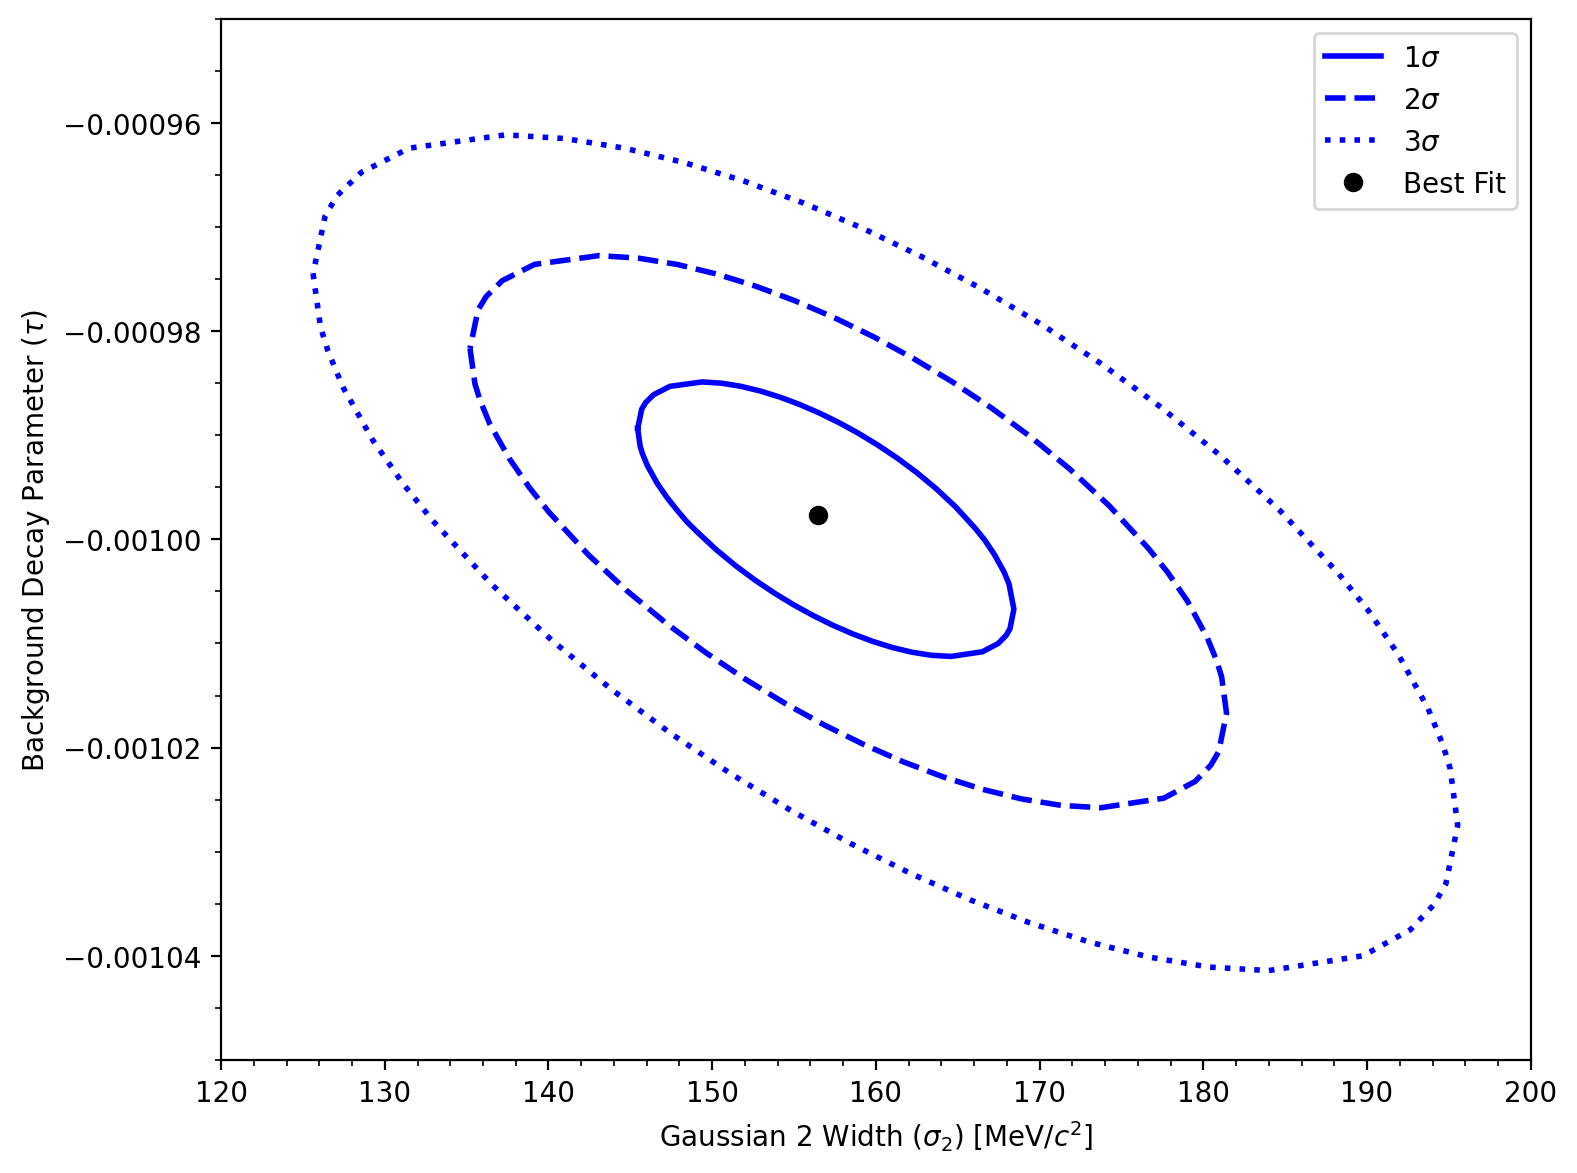

In [8]:
fig2, ax2 = plt.subplots(figsize=(8, 6))

# Append index 0 to the end of the arrays to close the contour loops
ax2.plot(np.append(x_c1, x_c1[0]), np.append(y_c1, y_c1[0]), color='blue', linestyle='-', linewidth=2, label=r'$1\sigma$')
ax2.plot(np.append(x_c2, x_c2[0]), np.append(y_c2, y_c2[0]), color='blue', linestyle='--', linewidth=2, label=r'$2\sigma$')
ax2.plot(np.append(x_c3, x_c3[0]), np.append(y_c3, y_c3[0]), color='blue', linestyle=':', linewidth=2, label=r'$3\sigma$')

# Plot best fit minimum if found
if best_fit_x is not None:
    ax2.plot(best_fit_x, best_fit_y, marker='o', markersize=6, color="black", label='Best Fit', linestyle='None')

ax2.set_xlabel(r'Gaussian 2 Width ($\sigma_2$) [MeV/$c^{2}$]')
ax2.set_ylabel(r'Background Decay Parameter ($\tau$)')

# Enforce strict axis limits mirroring the ROOT fix
ax2.set_xlim(120, 200)
ax2.set_ylim(-0.00105, -0.00095)

ax2.xaxis.set_minor_locator(AutoMinorLocator())
ax2.yaxis.set_minor_locator(AutoMinorLocator())
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()